# Uroglena bloom in Lake Geneva: PlanetScope SuperDove, 6 September 2021

In early September 2021, Lake Geneva showed a large bloom of the golden alga
*Uroglena*. From space, the bloom draws streaks, filaments and eddies over the whole
Grand Lac: the algae act as a tracer of the surface circulation.

This notebook quantifies these patterns on PlanetScope SuperDove images (8 bands, 3 m):

1. read a scene: top-of-atmosphere reflectance, water mask, averaging to 12 m;
2. choose the band that shows the bloom best;
3. analyse the central Grand Lac (09:37 UTC) at 12, 24, 48 and 96 m with
   {func}`~shades2shapes.diagnose_pyramid`, and keep the eddies found at several
   resolutions;
4. do the same for the western Grand Lac (10:26 UTC, another satellite), where a large
   gyre stands out;
5. compare the two areas and export the results.

It needs the `geo` extra (`pip install shades2shapes[geo]`). The images are not
distributed with the package (Planet licence): set `PLANET_DIR` below, or the
environment variable of the same name, to the folder of the order
(`*_AnalyticMS_8b_clip.tif`, `*_udm2_clip.tif` and `*_metadata_clip.xml` files).

In [1]:
import os
import re
import sys
from pathlib import Path

try:
    import shades2shapes as s2s
except ImportError:  # not installed: use the source tree of the repository
    src = next(p / "src" for p in [Path.cwd(), *Path.cwd().parents]
               if (p / "src" / "shades2shapes").is_dir())
    sys.path.insert(0, str(src))
    import shades2shapes as s2s

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import rioxarray  # noqa: F401  (.rio accessor)
import xarray as xr
from scipy import ndimage as ndi

%matplotlib inline
plt.rcParams["figure.dpi"] = 72
pd.set_option("display.precision", 3)
pd.set_option("display.width", 160)
print("shades2shapes", s2s.__version__)

shades2shapes 0.1.0


In [2]:
PLANET_DIR = Path(os.environ.get(
    "PLANET_DIR",
    "/data/satellite/planetscope/LakeGeneva_PS-SD_8B_06Sep2021_psscene_analytic_8b_udm2"))
FILES = PLANET_DIR / "files"
if not FILES.is_dir():
    raise FileNotFoundError(f"{FILES} not found: set PLANET_DIR")
sorted(f.name for f in FILES.glob("*_AnalyticMS_8b_clip.tif"))

['20210906_093708_51_2457_3B_AnalyticMS_8b_clip.tif',
 '20210906_102649_91_2414_3B_AnalyticMS_8b_clip.tif',
 '20210906_102652_21_2414_3B_AnalyticMS_8b_clip.tif',
 '20210906_102654_50_2414_3B_AnalyticMS_8b_clip.tif']

## 1. Reading a scene

The *analytic* product holds scaled radiances (uint16, 0 = no data). Each band is
converted to top-of-atmosphere (TOA) reflectance with the coefficient given in the XML
metadata. No atmospheric correction is applied: the analysis is about spatial
patterns, and each band is normalised anyway.

Water pixels are those that are clear in the usable-data mask (UDM2, band 1) and have
NDWI = (green − NIR) / (green + NIR) > 0.1. The mask is cleaned, then eroded by 30 m to
remove the shore, where land contaminates the water signal.

At 3 m, a scene is up to 11 000 × 6 000 px, more than needed for eddies of a few
kilometres. The bands are averaged over 4 × 4 blocks to 12 m, keeping only blocks of
pure water; the others are NaN.

In [3]:
def load_scene(scene_id, factor=4, ndwi_min=0.1, shore_px=10):
    """PlanetScope 8-band scene as TOA reflectance, water only, averaged by `factor`."""
    tif = FILES / f"{scene_id}_3B_AnalyticMS_8b_clip.tif"
    xml = (FILES / f"{scene_id}_3B_AnalyticMS_8b_metadata_clip.xml").read_text()
    coef = [float(v) for v in re.findall(r"reflectanceCoefficient>([0-9.eE+-]+)<", xml)]
    with rasterio.open(tif) as src, rasterio.open(FILES / f"{scene_id}_3B_udm2_clip.tif") as udm:
        names, crs, T = src.descriptions, src.crs, src.transform
        clear = udm.read(1) == 1
        green = src.read(4) * coef[3]
        nir = src.read(8) * coef[7]
        ndwi = (green - nir) / (green + nir + 1e-9)
        water = clear & (green > 0) & (ndwi > ndwi_min)
        water = ndi.binary_opening(water, iterations=2)
        water = ndi.binary_erosion(water, iterations=shore_px)
        H, W = (src.height // factor) * factor, (src.width // factor) * factor

        def block(a):
            return a[:H, :W].reshape(H // factor, factor, W // factor, factor).mean(axis=(1, 3))

        pure = block(water.astype(np.float32)) == 1
        bands = [np.where(pure, block(src.read(b).astype(np.float32) * coef[b - 1]), np.nan)
                 for b in range(1, 9)]
    x = T.c + T.a * factor * (np.arange(W // factor) + 0.5)
    y = T.f + T.e * factor * (np.arange(H // factor) + 0.5)
    da = xr.DataArray(np.stack(bands), dims=("band", "y", "x"),
                      coords={"band": list(names), "y": y, "x": x},
                      name="toa_reflectance")
    return da.rio.write_crs(crs)


def true_colour(da):
    rgb = da.sel(band=["red", "green", "blue"]).transpose("y", "x", "band").values
    # remove a dark offset per band (mostly the Rayleigh scattering of the atmosphere),
    # then the same gain for the 3 bands, to keep the colour balance
    rgb = rgb - np.nanpercentile(rgb, 1, axis=(0, 1))
    rgb = rgb / np.nanpercentile(rgb, 99.5)
    return np.nan_to_num(rgb.clip(0, 1) ** 0.7, nan=1.0)


def extent(da):
    dx, dy = float(da.x[1] - da.x[0]), float(da.y[1] - da.y[0])
    return [float(da.x[0]) - dx / 2, float(da.x[-1]) + dx / 2,
            float(da.y[-1]) + dy / 2, float(da.y[0]) - dy / 2]


def draw_box(ax, bbox, **kw):
    x0, y0, x1, y1 = bbox
    ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], **kw)

In [4]:
%%time
central = load_scene("20210906_093708_51_2457")
print(dict(central.sizes), central.rio.crs, central.rio.resolution())
print(f"water: {float(np.isfinite(central.sel(band='green')).mean()):.0%} of the grid")

{'band': 8, 'y': 1434, 'x': 2828} EPSG:32632 (12.0, -12.0)
water: 46% of the grid
CPU times: user 11.3 s, sys: 3.03 s, total: 14.3 s
Wall time: 14.3 s


The central Grand Lac at 09:37 UTC, between Lausanne and Montreux (north) and Évian (south), in
true colour (water only, the rest in white). The box is the analysed area: it avoids
the shores and, on the west, a straight radiometric step between two imaging frames of
the SuperDove sensor.

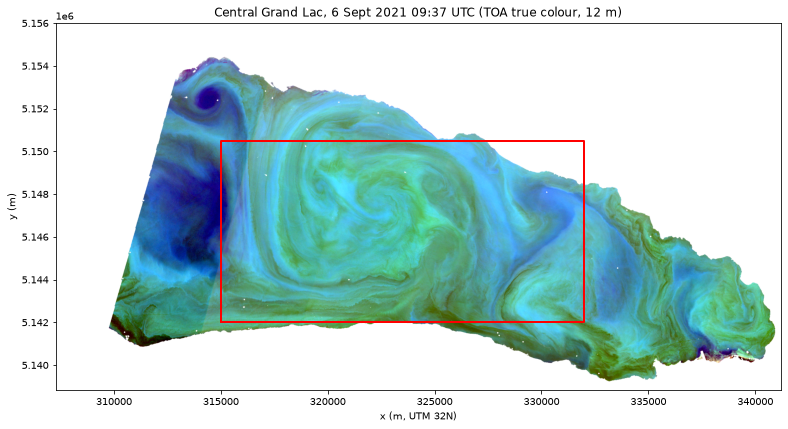

In [5]:
BBOX_CENTRAL = (315000, 5142000, 332000, 5150500)    # m, EPSG:32632 (UTM 32N)

fig, ax = plt.subplots(figsize=(13, 7))
ax.imshow(true_colour(central), extent=extent(central))
draw_box(ax, BBOX_CENTRAL, color="red", lw=2)
ax.set_title("Central Grand Lac, 6 Sept 2021 09:37 UTC (TOA true colour, 12 m)")
ax.set_xlabel("x (m, UTM 32N)")
ax.set_ylabel("y (m)");

## 2. Which band?

The bloom stands out in the blue and green bands, where the algae scatter light. In the
red, red-edge and NIR, the water signal is weak and the image is dominated by stripes
at the boundaries of the sensor frames, which would be detected as straight
"filaments". We use **green_i** (531 nm); blue gives similar results.

band,blue,green_i,red,nir
relative 5-95 % spread,0.151,0.178,0.121,0.265


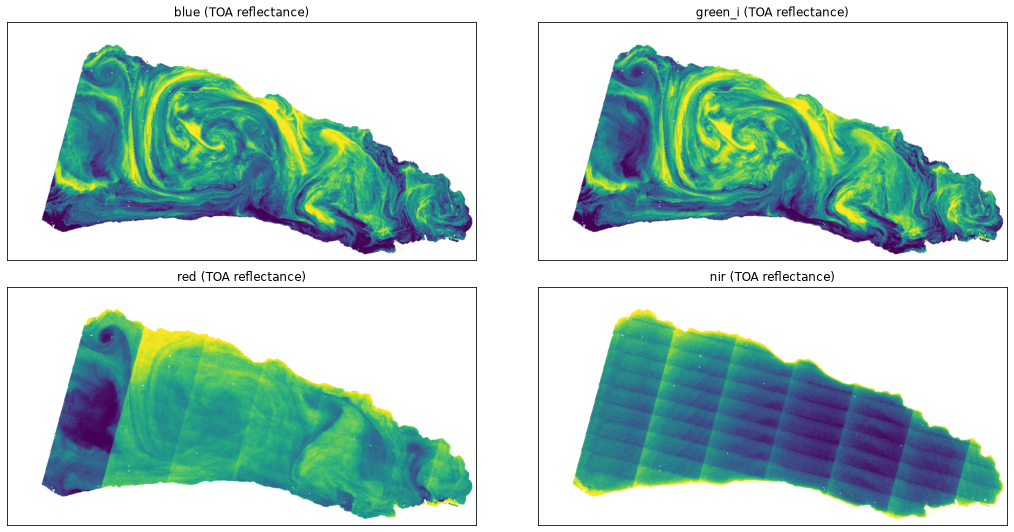

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(15, 7.5))
for a, b in zip(ax.ravel(), ["blue", "green_i", "red", "nir"]):
    v = central.sel(band=b)
    lo, hi = np.nanpercentile(v, [2, 98])
    a.imshow(v, vmin=lo, vmax=hi, cmap="viridis", extent=extent(central))
    a.set_title(f"{b} (TOA reflectance)")
    a.set_xticks([]); a.set_yticks([])
fig.tight_layout()

v = central.sel(band=["blue", "green_i", "red", "nir"])
spread = (v.quantile(0.95, dim=["x", "y"]) - v.quantile(0.05, dim=["x", "y"])) / v.median(dim=["x", "y"])
spread.to_series().rename("relative 5-95 % spread").to_frame().T

## 3. Central Grand Lac at four resolutions

{func}`~shades2shapes.diagnose_pyramid` coarsens the 12 m image by 2, 4 and 8
(24, 48, 96 m), cuts the box from each level, fills the few NaN pixels left in it
(about 4 %, small gaps of the water mask) from their neighbours, and diagnoses each
level. The pixel size comes from the georeferencing.

In [7]:
%%time
p_central = s2s.diagnose_pyramid(central, factors=(1, 2, 4, 8), channel="green_i",
                                 bbox=BBOX_CENTRAL, unit="km")
p_central.levels

CPU times: user 15.6 s, sys: 82.8 ms, total: 15.7 s
Wall time: 15.6 s


,pixel_size,shape,nodata_fraction,status
level,,,,
x1,0.012,1417x709,0.041,ok
x2,0.024,708x354,0.041,ok
x4,0.048,354x177,0.040,ok
x8,0.096,177x88,0.038,ok


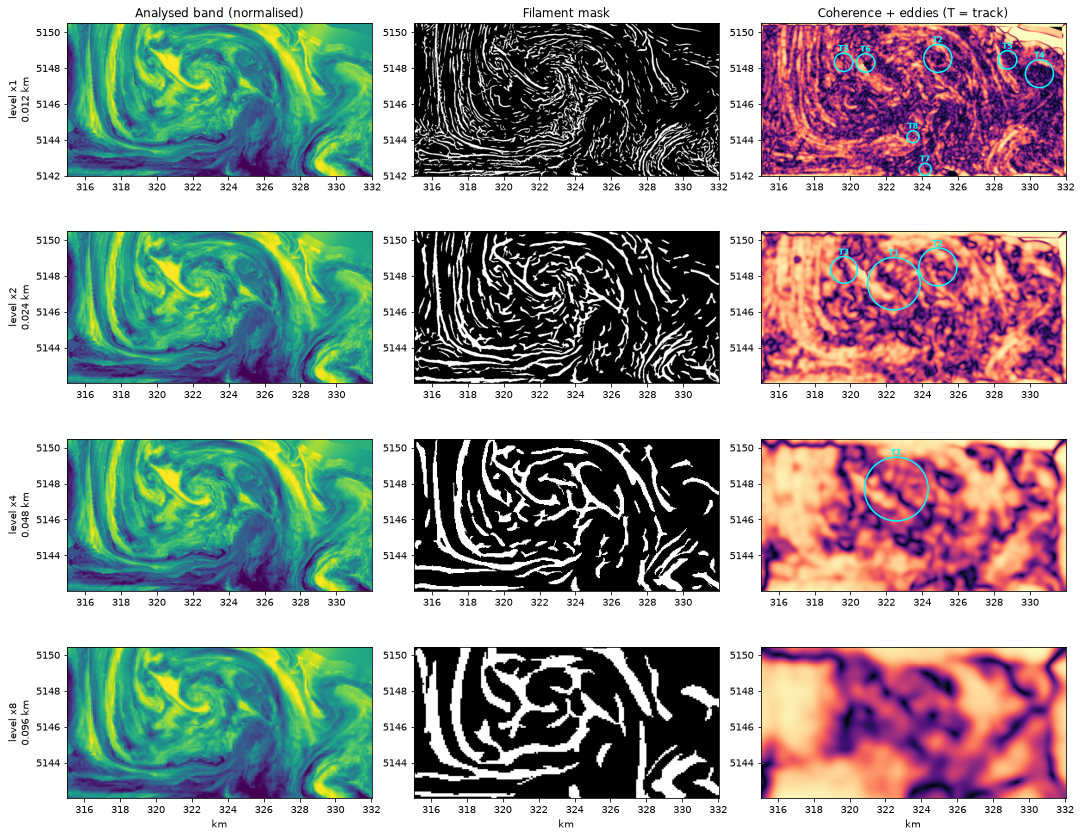

In [8]:
fig = p_central.plot()

Rows: 12, 24, 48 and 96 m. Columns: the analysed band (normalised), the filament
mask and the orientation coherence, with the eddies labelled by track.

The bloom streaks form long, coherent filaments wrapped around a large gyre
in the middle of the box, with smaller eddies on its edges. At 12 m the mask also
picks up thin streaks within the larger bands; at 96 m only the main bands remain.

In [9]:
p_central.metrics_table(s2s.multiscale.PYRAMID_METRICS)

,pixel_size,filament_fraction,skeleton_density_phys,branch_length_mean_phys,junction_endpoint_ratio,coherence_filaments,orientation_order,glcm_correlation_decay,spectral_slope,fractal_dimension,n_eddies
level,,,,,,,,,,,
x1,0.012,0.177,3.038,0.196,0.456,0.548,0.125,0.948,-2.952,1.645,7.0
x2,0.024,0.210,1.875,0.442,0.430,0.666,0.114,0.894,-2.990,1.631,3.0
x4,0.048,0.227,1.025,0.857,0.444,0.691,0.080,0.800,-2.902,1.571,1.0
x8,0.096,0.277,0.722,1.322,0.534,0.641,0.084,0.650,-2.808,1.579,0.0


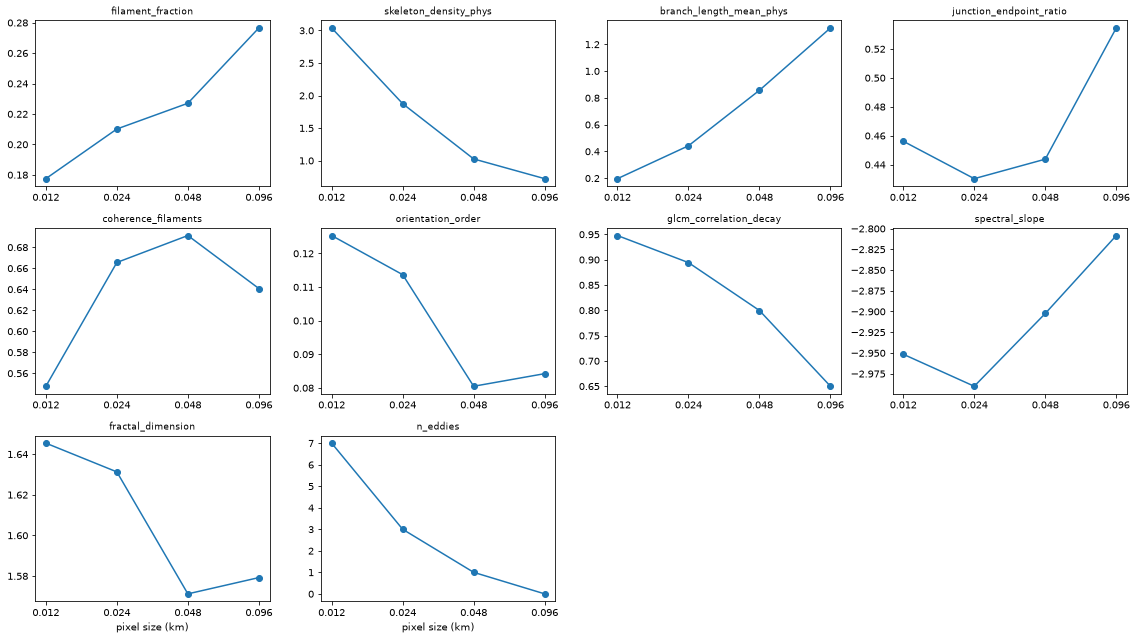

In [10]:
fig = p_central.plot_metrics()

Reading across levels:

* the **filament coherence** (~0.55–0.68) is high at every level: the streaks are
  long and locally parallel, as expected for a tracer stretched by the currents;
* the **orientation order** stays low (~0.1): there is no dominant direction over the
  box, because the filaments wrap around eddies;
* the **mean branch length** in km grows with the pixel size: the fine levels split
  the bands into short pieces, the coarse ones keep only the long fronts;
* the **GLCM correlation decay** drops at coarse levels, where 1 and 5 px are far apart
  on the ground.

## Eddy tracks

An eddy found at several resolutions, at the same place and with a similar radius, is
a robust structure.

In [11]:
p_central.eddy_tracks

,track,n_levels,levels,x_map,y_map,radius_map,radius_px_finest,max_significance,mean_alignment,lon,lat
0,1,2,"x2,x4",322491.0,5.148e+06,1620.0,135.0,2.963,0.585,6.688,46.459
1,2,2,"x1,x2",324876.0,5.149e+06,918.0,76.5,2.891,0.676,6.719,46.467
2,3,2,"x1,x2",319632.0,5.148e+06,630.0,52.5,2.067,0.628,6.651,46.464
3,4,1,x1,330543.0,5.148e+06,780.0,65.0,1.935,0.603,6.793,46.461
4,5,1,x1,328767.0,5.148e+06,516.0,43.0,1.685,0.577,6.770,46.468
5,6,1,x1,320847.0,5.148e+06,516.0,43.0,1.685,0.613,6.667,46.464
6,7,1,x1,324171.0,5.142e+06,336.0,28.0,1.533,0.586,6.712,46.412
7,8,1,x1,323499.0,5.144e+06,336.0,28.0,1.531,0.645,6.703,46.428


In [12]:
def describe_tracks(p):
    for _, t in p.eddy_tracks[p.eddy_tracks["n_levels"] >= 2].iterrows():
        print(f"track {t['track']}: levels {t['levels']}, radius {t['radius_map'] / 1000:.1f} km,"
              f" at {t['lon']:.3f} E, {t['lat']:.3f} N")

describe_tracks(p_central)

track 1: levels x2,x4, radius 1.6 km, at 6.688 E, 46.459 N
track 2: levels x1,x2, radius 0.9 km, at 6.719 E, 46.467 N
track 3: levels x1,x2, radius 0.6 km, at 6.651 E, 46.464 N


Track 1 (1.6 km, found at 24 and 48 m) is centred on the large gyre of the box, but
covers only its inner part: the outer ring, about 3 km in radius, is at the limit of
the largest radius tested (a third of the box height, 2.8 km here), and the lake is not
wide enough for a taller box. Tracks 2 and 3 (0.9 and 0.6 km, at 12 and 24 m) are
smaller eddies on its northern edge. The eddies seen at a single level, mostly at
12 m, are small curls of the streaks.

The diagnosis of one level is a regular {class}`~shades2shapes.Diagnosis`:

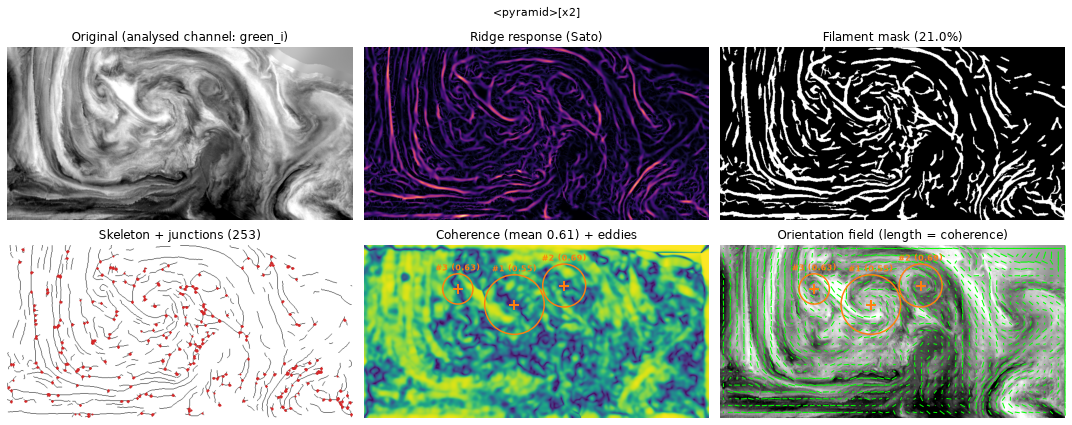

In [13]:
d24 = p_central.diagnoses["x2"]
fig = d24.plot()

## 4. Western Grand Lac: a large gyre

The 10:26 UTC strip (satellite 2414) covers the western Grand Lac. A large gyre,
about 6 km across, is clearly visible, with bloom filaments spiralling into it.

CPU times: user 12.2 s, sys: 3.37 s, total: 15.6 s
Wall time: 15.6 s


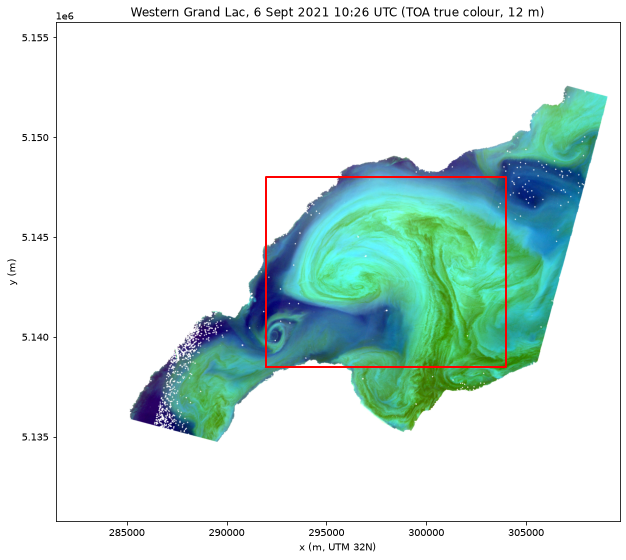

In [14]:
%%time
west = load_scene("20210906_102652_21_2414")
BBOX_WEST = (292000, 5138500, 304000, 5148000)

fig, ax = plt.subplots(figsize=(11, 9))
ax.imshow(true_colour(west), extent=extent(west))
draw_box(ax, BBOX_WEST, color="red", lw=2)
ax.set_title("Western Grand Lac, 6 Sept 2021 10:26 UTC (TOA true colour, 12 m)")
ax.set_xlabel("x (m, UTM 32N)")
ax.set_ylabel("y (m)");

In [15]:
%%time
p_west = s2s.diagnose_pyramid(west, factors=(1, 2, 4, 8), channel="green_i",
                              bbox=BBOX_WEST, unit="km")
p_west.levels

CPU times: user 13.4 s, sys: 60.8 ms, total: 13.4 s
Wall time: 13.4 s


,pixel_size,shape,nodata_fraction,status
level,,,,
x1,0.012,1000x792,0.064,ok
x2,0.024,500x396,0.063,ok
x4,0.048,250x198,0.061,ok
x8,0.096,125x99,0.059,ok


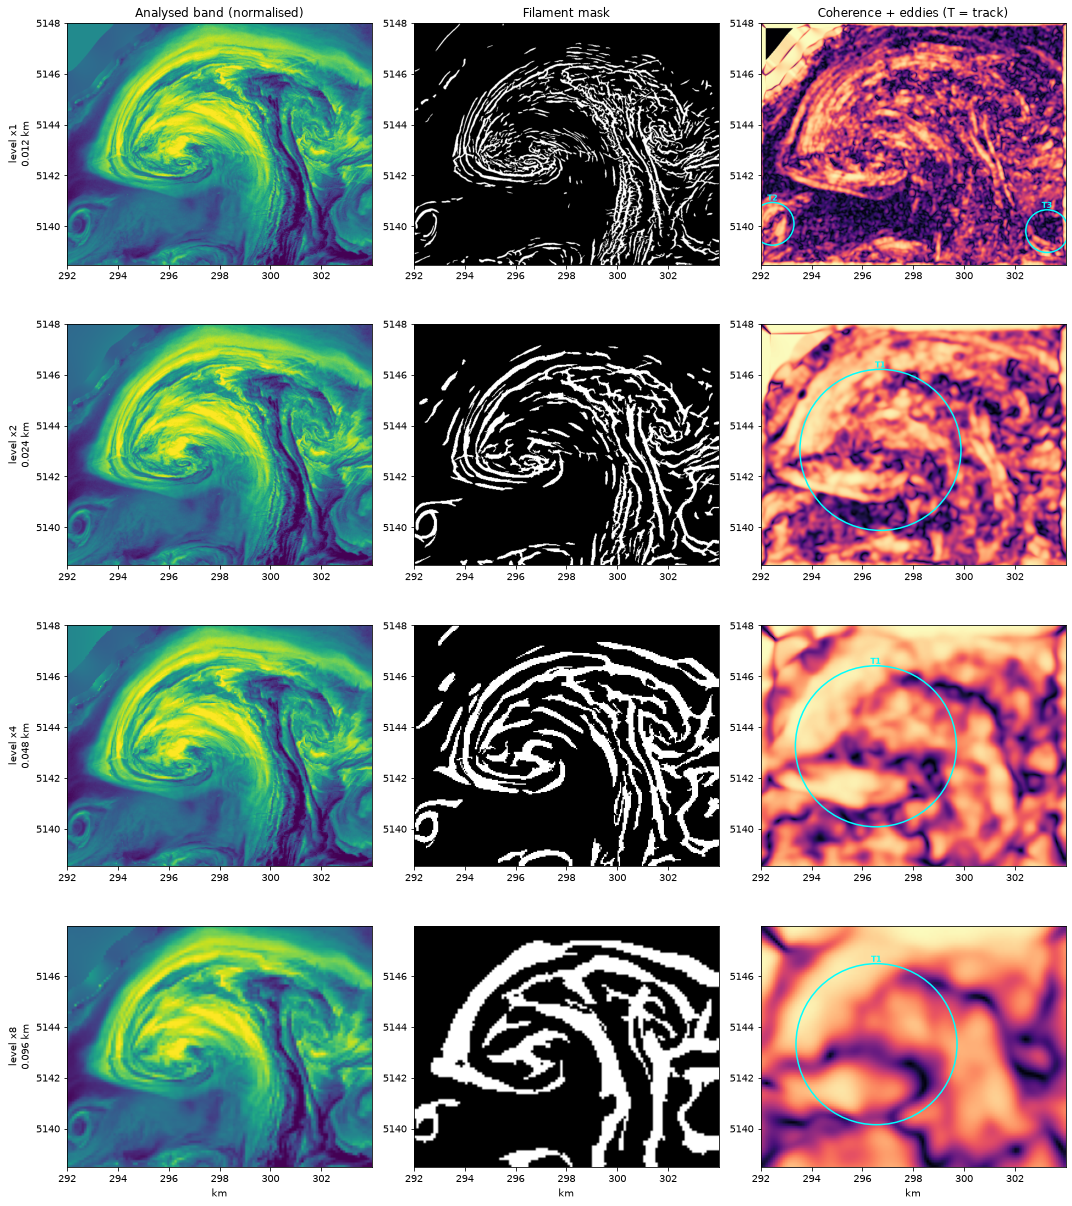

In [16]:
fig = p_west.plot()

In [17]:
p_west.eddy_tracks

,track,n_levels,levels,x_map,y_map,radius_map,radius_px_finest,max_significance,mean_alignment,lon,lat
0,1,3,"x2,x4,x8",296600.0,5.143e+06,3168.0,264.0,6.329,0.634,6.353,46.412
1,2,1,x1,292470.0,5.140e+06,840.0,70.0,3.584,0.730,6.301,46.383
2,3,1,x1,303270.0,5.140e+06,840.0,70.0,2.537,0.589,6.442,46.383


In [18]:
describe_tracks(p_west)

track 1: levels x2,x4,x8, radius 3.2 km, at 6.353 E, 46.412 N


The gyre is found at 24, 48 and 96 m with a radius of 3.2 km and a significance of
6.3, the strongest eddy of both scenes. At 12 m, only two small eddies near the edges
of the box are kept (one of them, in the south-west corner, is a clear 0.8 km eddy):
the gyre spans the whole box height, at the limit of the largest radius tested.

## 5. The two areas compared

At the same resolution (24 m), the main metrics of the two areas:

In [19]:
cols = ["filament_fraction", "skeleton_density_phys", "branch_length_mean_phys",
        "junction_endpoint_ratio", "coherence_filaments", "orientation_order",
        "glcm_correlation_decay", "spectral_slope", "fractal_dimension", "n_eddies",
        "eddy_dominant_radius_phys"]
pd.DataFrame({"central (09:37)": p_central.metrics_table(cols).loc["x2"],
              "west (10:26)": p_west.metrics_table(cols).loc["x2"]})

,central (09:37),west (10:26)
pixel_size,0.024,0.024
filament_fraction,0.210,0.171
skeleton_density_phys,1.875,1.707
branch_length_mean_phys,0.442,0.330
junction_endpoint_ratio,0.430,0.610
coherence_filaments,0.666,0.642
orientation_order,0.114,0.193
glcm_correlation_decay,0.894,0.896
spectral_slope,-2.990,-2.871
fractal_dimension,1.631,1.624


Both areas share the signature of a tracer stirred by the lake circulation: coherent
filaments (0.64–0.67), little preferred direction, and kilometre-scale eddies found at
several resolutions. The western area, organised around a single gyre, has a larger
dominant eddy (3.2 vs 1.5 km), a more ordered orientation (0.19 vs 0.11) and a more
connected network (junction/endpoint ratio 0.61 vs 0.43). To test whether such differences are significant, compare several images
per area or date with {func}`~shades2shapes.discriminate` (one image per class only
gives an optimistic, tile-level estimate).

## 6. Export

Tables, JSON and figures of both analyses, and the 24 m filament mask of the central
area as a GeoTIFF, which can be opened in a GIS. Figures are saved from the returned
objects: with `plots=True`, `save` switches matplotlib to a non-interactive backend,
which stops inline plots.

In [20]:
out = Path("out_uroglena")
for name, p in (("central", p_central), ("west", p_west)):
    o = p.save(out / name, plots=False)
    p.plot().savefig(o / "pyramid.png", dpi=90)
    p.plot_metrics().savefig(o / "metrics_by_level.png", dpi=100)
plt.close("all")
d24.to_xarray().mask.rio.to_raster(out / "central" / "filament_mask_24m.tif")
sorted(str(f.relative_to(out)) for f in out.rglob("*") if f.is_file())

['central/eddies.csv',
 'central/eddy_tracks.csv',
 'central/filament_mask_24m.tif',
 'central/levels.csv',
 'central/metrics_by_level.csv',
 'central/metrics_by_level.png',
 'central/pyramid.json',
 'central/pyramid.png',
 'central/summary.txt',
 'west/eddies.csv',
 'west/eddy_tracks.csv',
 'west/levels.csv',
 'west/metrics_by_level.csv',
 'west/metrics_by_level.png',
 'west/pyramid.json',
 'west/pyramid.png',
 'west/summary.txt']

## Caveats

* TOA reflectance: haze and glint gradients are not removed, but the analysis is about
  spatial patterns, and the band is percentile-normalised.
* SuperDove frame boundaries create straight radiometric steps and stripes, mostly in
  the red and NIR: use the blue or green bands and keep the boxes away from them.
* The bloom is a tracer: the eddies are inferred from the geometry of the streaks, not
  from currents, and their rotation sense is not recovered.
* Gaps of the water mask inside the boxes (about 4–6 %) are filled from their
  neighbours; larger gaps (land, clouds) must be left out of the box.